<a href="https://colab.research.google.com/github/noor486/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/noor486/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/noor486/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("../..")

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)
print("Working dir:", os.getcwd())

Working dir: /content/flyrank-ml-internship


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd, numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)

features = ["search_volume", "competition", "cpc", "word_count",
            "impressions_90d", "sessions_90d", "content_age_days",
            "days_since_last_update", "ctr", "avg_position"]
X = df[features].replace([np.inf, -np.inf], np.nan).fillna(0)
y = df["is_declining_label"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=df["client_id"]))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

rf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)

test_df = df.iloc[test_idx].copy()
test_df["model_score"] = rf.predict_proba(X_test)[:, 1]

# Reason codes: which signal(s) actually justify this page's placement
def reason_code(row):
    codes = []
    if row["days_since_last_update"] >= 180 and row["impressions_90d"] >= 500:
        codes.append("stale_visible_page")
    if row["avg_position"] <= 20 and row["ctr"] < 0.5 and row["impressions_90d"] >= 500:
        codes.append("low_ctr_visible_page")
    if row["model_score"] >= 0.65:
        codes.append("model_decline_risk")
    return ",".join(codes) if codes else "low_confidence"

test_df["reason_code"] = test_df.apply(reason_code, axis=1)
test_df["action"] = test_df["model_score"].apply(
    lambda s: "review_for_refresh" if s >= 0.65 else ("monitor" if s >= 0.4 else "no_action")
)

queue = test_df.sort_values("model_score", ascending=False)[
    ["content_id", "client_id", "model_score", "reason_code", "action",
     "impressions_90d", "days_since_last_update", "avg_position", "ctr"]
]
queue.to_csv("work/outputs/content_action_playbook.csv", index=False)
print(f"Wrote {len(queue)} ranked rows.")
queue.head(10)

Wrote 7115 ranked rows.


,content_id,client_id,model_score,reason_code,action,impressions_90d,days_since_last_update,avg_position,ctr
22730,content_bb1edbf0ba6c,client_4e07408562,0.804846,"low_ctr_visible_page,model_decline_risk",review_for_refresh,1290,104,12.4,0.00
12651,content_2a228ce7aa1b,client_8527a891e2,0.801915,model_decline_risk,review_for_refresh,155,92,7.5,0.00
21729,content_7766ffacdcfa,client_8527a891e2,0.800213,"low_ctr_visible_page,model_decline_risk",review_for_refresh,657,104,9.3,0.00
22042,content_2ba626fea4d6,client_8527a891e2,0.799646,model_decline_risk,review_for_refresh,360,104,7.2,0.00
13215,content_98aa0aecb1d9,client_8527a891e2,0.799189,"low_ctr_visible_page,model_decline_risk",review_for_refresh,5190,104,5.1,0.06
22526,content_1d0963b56227,client_4e07408562,0.794483,model_decline_risk,review_for_refresh,3445,104,39.0,0.09
6228,content_e988c1699454,client_8527a891e2,0.794313,model_decline_risk,review_for_refresh,2197,104,21.5,0.00
18475,content_197a5b1ed096,client_8527a891e2,0.792919,"low_ctr_visible_page,model_decline_risk",review_for_refresh,605,102,14.4,0.00
12472,content_884c401ce126,client_8527a891e2,0.792743,model_decline_risk,review_for_refresh,101,92,23.1,0.00
25063,content_29884c0f9255,client_8527a891e2,0.790775,model_decline_risk,review_for_refresh,428,102,12.3,0.00


## 1. Ranked Actions + Reason Codes

Each page gets a model score (0-1, higher = more likely declining), an action
label (review_for_refresh / monitor / no_action), and a transparent reason
code explaining WHY it landed there -- stale_visible_page, low_ctr_visible_page,
model_decline_risk, or combinations. A reviewer should never see a ranked page
without being able to see why it's there.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. Intended Use and Limits

**Intended use:** a weekly/monthly triage aid for a content review team with
limited hours -- helping them pick which pages to look at FIRST, not deciding
what to do to them.

**Archetype -> action mapping:**
- stale_visible_page -> refresh candidate (update content, refresh dates/facts)
- low_ctr_visible_page -> metadata/snippet review (title, meta description)
- model_decline_risk (no clear reason code) -> flag for human investigation
  before any action -- the model sees something, but we don't yet know what

**The decay/refresh insight:** per my Week 5 permutation importance,
impressions_90d and content_age_days matter most, while days_since_last_update
alone (my original baseline's whole basis) carries little independent signal
once other features are available -- staleness alone is a weaker signal than
intuition suggests.

**Limits:** validated on a ~30k-row starter slice with client-holdout
validation, Precision@50 = 0.640 vs. baseline 0.620 -- a real but modest
improvement, not a dramatic one. This is decision-support, not a guarantee
any flagged page will actually recover if refreshed.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human Review Rules and What Should NOT Be Automated

**Every action requires human review before execution** -- this playbook
produces a candidate list, not autonomous actions.

**What should NEVER be automated:**
- Actually editing or publishing content changes -- a human writer/editor
  must review and approve every refresh, always.
- Deleting or de-indexing any page based on a low score -- this playbook
  never recommends removal, only review priority.
- Client-facing communication about page performance -- scores are internal
  triage aids, not client deliverables, without human framing.
- Any action on a page with reason_code == "low_confidence" -- these pages
  should be skipped entirely, not force-ranked into an action.

**Human review checklist before acting on any "review_for_refresh" page:**
- Confirm the reason code actually makes sense for this specific page
  (read the real page, don't just trust the score)
- Check for consolidation/seasonality/noise explanations before assuming decline
- Confirm the page isn't already scheduled for a redesign/removal for
  unrelated business reasons

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Light monitoring signal: how much does the score distribution shift over time?
score_summary = {
    "mean_score": float(test_df["model_score"].mean()),
    "share_flagged_review": float((test_df["action"] == "review_for_refresh").mean()),
    "share_low_confidence": float((test_df["reason_code"] == "low_confidence").mean()),
}
import json
with open("work/outputs/playbook_metrics.json", "w") as f:
    json.dump(score_summary, f, indent=2)
print(score_summary)

{'mean_score': 0.5265047903857482, 'share_flagged_review': 0.27603654251581167, 'share_low_confidence': 0.5246661981728742}


**Retrain triggers (light, practical):**
- If share_flagged_review shifts by more than ~15 percentage points month-over-month
  without a known cause (e.g. a major site migration), re-check the model --
  something about the underlying data distribution likely changed.
- Retrain on a rolling basis (e.g. quarterly) rather than continuously --
  this is a decision-support tool, not a live production system requiring
  real-time updates.
- If a reviewer consistently overrides "review_for_refresh" pages as wrong
  (tracked informally), treat that as a signal to revisit feature choices,
  not just retrain on more data.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

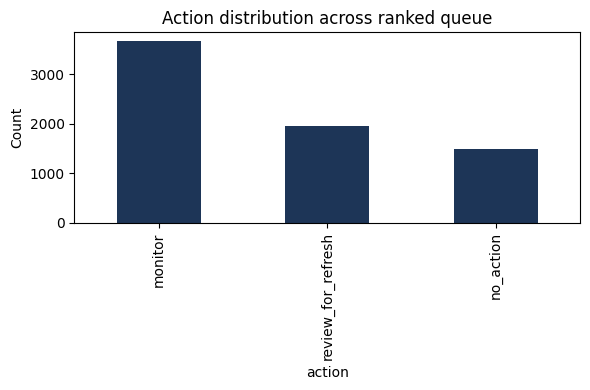

Saved work/figures/action_distribution.png
Saved work/outputs/content_action_playbook.csv (queue, stays out of git)
Saved work/outputs/playbook_metrics.json (commit this -- it's a receipt)


In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
test_df["action"].value_counts().plot(kind="bar", ax=ax, color="#1D3557")
ax.set_title("Action distribution across ranked queue")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("work/figures/action_distribution.png", dpi=150)
plt.show()
print("Saved work/figures/action_distribution.png")
print("Saved work/outputs/content_action_playbook.csv (queue, stays out of git)")
print("Saved work/outputs/playbook_metrics.json (commit this -- it's a receipt)")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.